In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")

C:\Users\DELL\AppData\Local\Temp\ipykernel_25988\3419646863.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [4]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
df = train.merge(store, on = "Store", how = "left")

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [7]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [10]:
daily_sales = df.groupby('Date')['Sales'].sum()

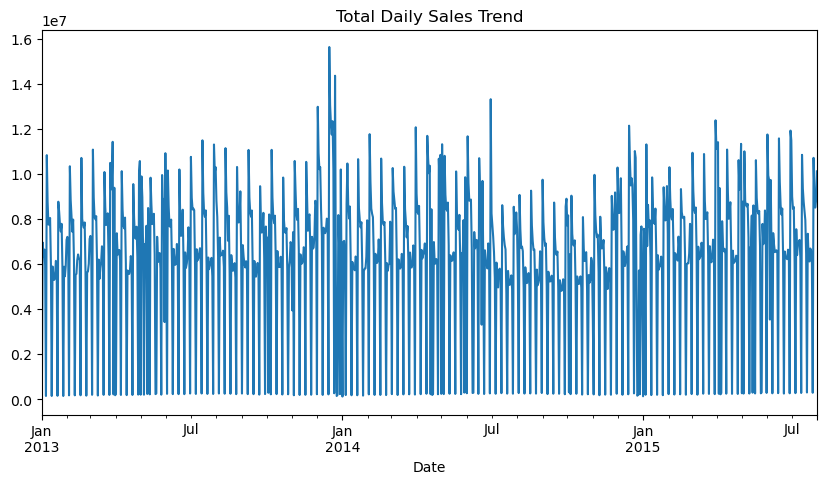

In [11]:
plt.figure(figsize=(10, 5))
daily_sales.plot()
plt.title("Total Daily Sales Trend")
plt.show()

In [12]:
df = df[df['Open'] == 1]

In [13]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
year                              0
month                             0
day                               0
dtype: int64

In [14]:
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace = True)

df.fillna(0, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_25988\3615196434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace = True)


In [15]:
df = pd.get_dummies(df, columns=[
    'StoreType',
    'Assortment',
    'StateHoliday'
], drop_first=True)

In [16]:
y = df['Sales']


In [17]:
X = df.drop(['Sales', 'Date', 'Customers'], axis=1)

In [18]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

In [19]:
y_train = y[:train_size]
y_test = y[train_size:]

In [23]:
X.dtypes

Store                          int64
DayOfWeek                      int32
Open                           int64
Promo                          int64
SchoolHoliday                  int64
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
year                           int32
month                          int32
day                            int32
StoreType_b                     bool
StoreType_c                     bool
StoreType_d                     bool
Assortment_b                    bool
Assortment_c                    bool
StateHoliday_0                  bool
StateHoliday_a                  bool
StateHoliday_b                  bool
StateHoliday_c                  bool
dtype: object

In [24]:
X = X.select_dtypes(include=['int64', 'float64'])

In [ ]:
y = df['Sales']

X = df.drop(['Sales', 'Date', 'Customers'], axis = 1)

X = X.select_dtypes(include=['int64', 'float64'])

train_size = int(len(df) * 0.8)

In [28]:
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [21]:
X = df.drop(['Sales', 'Date', 'Customers', 'PromoInterval'], axis = 1)

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1100.202348432498


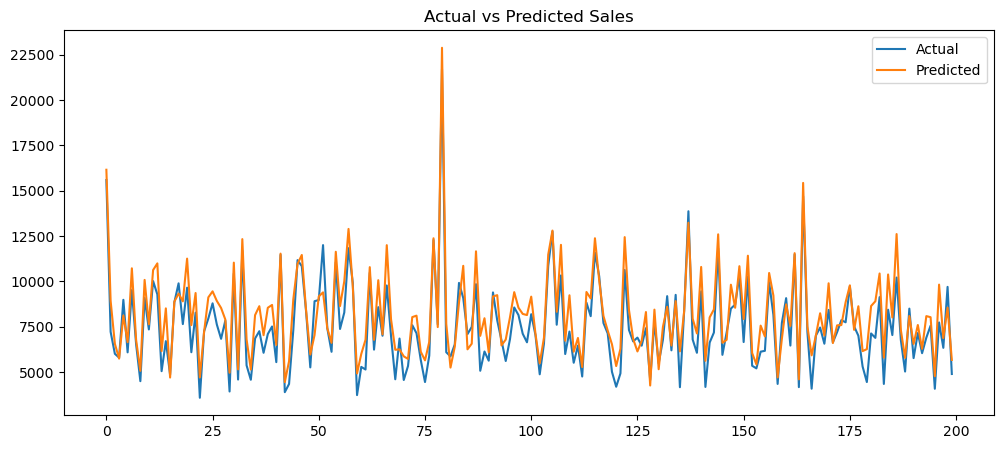

In [31]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label = 'Actual')
plt.plot(y_pred[:200], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [33]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

feature_importance.head(10)

Store                        0.283425
CompetitionDistance          0.265731
Promo                        0.181629
CompetitionOpenSinceMonth    0.093029
CompetitionOpenSinceYear     0.088651
Promo2SinceWeek              0.038793
Promo2SinceYear              0.037770
SchoolHoliday                0.006255
Promo2                       0.004717
Open                         0.000000
dtype: float64

In [34]:
df = df.sort_values(by = ['Store', 'Date'])

In [44]:
df['Date'] = pd.to_datetime(df['Date'])

In [45]:
df['day_of_week'] = df['Date'].dt.dayofweek

In [46]:
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [52]:
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

In [53]:
#df['lag_1'] = df.groupby('Store')['Sales'].shift(1)
df['week_of_year'] = df['Date'].dt.isocalendar().week
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [50]:
df = df.dropna()

In [64]:
df = df.sort_values('Date')

train = df[df['Date'] < '2025-01-01']
test = df[df['Date'] >= '2015-01-01']

X_train = train.drop(['Sales', 'Date', 'Customers'], axis = 1)
y_train = train['Sales']

X_test = test.drop(['Sales', 'Date', 'Customers'], axis = 1)
y_test = test['Sales']

In [66]:
df = df.drop('PromoInterval', axis = 1)

In [67]:
X_train = X_train.select_dtypes(include = ['int64', 'float64'])
X_test = X_test.select_dtypes(include=['int64', 'float64'])

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print(mae)

303.58018667615494


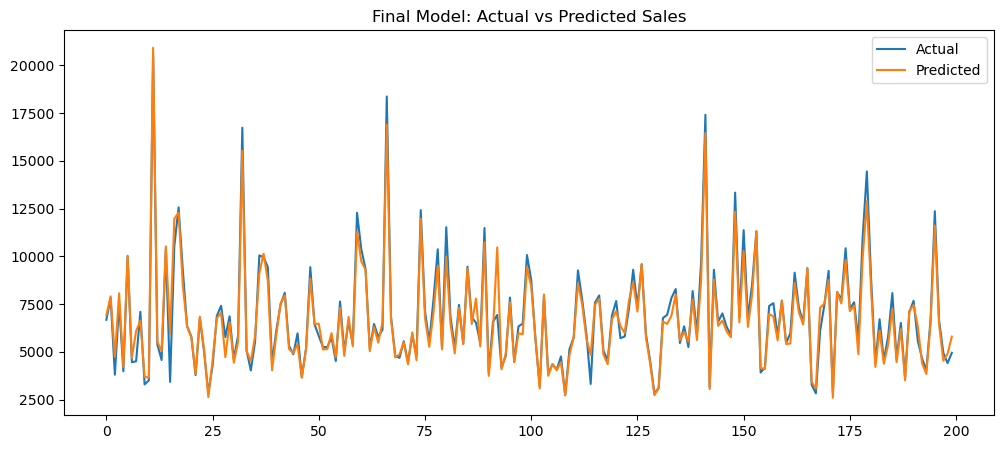

In [71]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label = 'Actual')
plt.plot(preds[:200], label = 'Predicted')
plt.legend()
plt.title("Final Model: Actual vs Predicted Sales")
plt.show()

In [72]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index = X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

lag1                         0.322201
lag_1                        0.299497
rolling_mean-7               0.158129
CompetitionDistance          0.049648
Store                        0.043999
Promo                        0.042954
is_weekend                   0.018764
CompetitionOpenSinceYear     0.018422
CompetitionOpenSinceMonth    0.016177
Promo2SinceWeek              0.013825
dtype: float64